In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque

In [2]:
# 1. LOAD DATA

outdir = Path("project3_outputs")

# load numpy versions
mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

# optional: load names from covariance csv for plotting
Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)

# load feasible portfolio weights
weights_df = pd.read_csv("feasible_weights.csv")
print("\nColumns in feasible_weights.csv:", weights_df.columns.tolist())

action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

print("Number of feasible actions:", len(action_grid))
print(weights_df.head())

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]

Columns in feasible_weights.csv: ['w1', 'w2', 'w3']
Number of feasible actions: 231
    w1    w2    w3
0  0.0  0.00  1.00
1  0.0  0.05  0.95
2  0.0  0.10  0.90
3  0.0  0.15  0.85
4  0.0  0.20  0.80


In [3]:
# 2. REWARD FUNCTION
REWARD_DEFINITION = r"""
Reward definition used in this project:

For portfolio weights w_t and next-period simulated asset return vector r_{t+1},

the portfolio return is
    r_{p,t+1} = w_t' r_{t+1}

and the one-period reward is
    R_{t+1} = r_{p,t+1} - (gamma / 2) * r_{p,t+1}^2.

Interpretation:
- the first term rewards higher realized portfolio return;
- the second term penalizes large realized portfolio outcomes in a
  mean-variance-consistent way controlled by gamma >= 0.
"""


def portfolio_return(weights, asset_returns):
    w = np.asarray(weights, dtype=float)
    r = np.asarray(asset_returns, dtype=float)

    if w.ndim != 1 or r.ndim != 1:
        raise ValueError("weights and asset_returns must both be 1D arrays")
    if w.shape[0] != r.shape[0]:
        raise ValueError("weights and asset_returns must have the same length")
    if not np.isfinite(w).all() or not np.isfinite(r).all():
        raise ValueError("weights and asset_returns must contain only finite values")

    return float(np.dot(w, r))


def mean_variance_reward(weights, asset_returns, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")

    rp = portfolio_return(weights, asset_returns)
    reward = rp - 0.5 * gamma * (rp ** 2)
    return float(reward)


def reward_components(weights, asset_returns, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")

    rp = portfolio_return(weights, asset_returns)
    return_term = float(rp)
    risk_penalty = float(0.5 * gamma * (rp ** 2))
    total_reward = float(return_term - risk_penalty)

    return {
        "portfolio_return": float(rp),
        "reward_return_term": return_term,
        "reward_risk_penalty": risk_penalty,
        "total_reward": total_reward,
    }

In [4]:
# 3. ENVIRONMENT
def sample_one_return(mu, Sigma, rng):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    return rng.multivariate_normal(mean=mu, cov=Sigma)

In [5]:
# 4. EPSILON-GREEDY POLICY
def epsilon_greedy_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(Q)))
    return int(np.argmax(Q))

In [6]:
# 5. Q-LEARNING TRAINING LOOP
def train_q_learning(
        mu,
        Sigma,
        action_grid,
        gamma=3.0,
        alpha=0.05,
        beta=0.001,
        discount=0.95,
        max_iter=50000,
        convergence_window=2000,
        q_tol=1e-10,
        seed=42,
        verbose=True
):
    """
    Stateless Q-learning:
        Q(a_t) <- Q(a_t) + alpha * [reward + discount * max_a' Q(a') - Q(a_t)]

    Main convergence rule:
        best action unchanged for the last `convergence_window` iterations
    """
    rng = np.random.default_rng(seed)

    n_actions = len(action_grid)
    Q = np.zeros(n_actions, dtype=float)

    reward_history = []
    epsilon_history = []
    action_history = []
    best_action_history = []
    q_max_history = []
    q_change_history = []

    best_action_window = deque(maxlen=convergence_window)
    small_q_change_window = deque(maxlen=convergence_window)

    converged = False
    convergence_iter = None

    for t in range(1, max_iter + 1):
        epsilon = float(np.exp(-beta * t))
        old_Q = Q.copy()

        # choose action
        a_idx = epsilon_greedy_action(Q, epsilon, rng)
        w = action_grid[a_idx]

        # sample next return
        r_next = sample_one_return(mu, Sigma, rng)

        # reward
        reward = mean_variance_reward(w, r_next, gamma)

        # Q update
        td_target = reward + discount * np.max(Q)
        td_error = td_target - Q[a_idx]
        Q[a_idx] = Q[a_idx] + alpha * td_error

        # logs
        current_best_idx = int(np.argmax(Q))
        q_change = float(np.max(np.abs(Q - old_Q)))

        reward_history.append(reward)
        epsilon_history.append(epsilon)
        action_history.append(a_idx)
        best_action_history.append(current_best_idx)
        q_max_history.append(float(np.max(Q)))
        q_change_history.append(q_change)

        best_action_window.append(current_best_idx)
        small_q_change_window.append(q_change < q_tol)

        # convergence check
        if t >= convergence_window:
            best_action_stable = (len(set(best_action_window)) == 1)
            q_changes_small = all(small_q_change_window)

            if best_action_stable:
                converged = True
                convergence_iter = t

                if verbose:
                    print(f"Converged at iteration {t}")
                    print(f"Best action index: {current_best_idx}")
                    print(f"Best weights: {action_grid[current_best_idx]}")
                    print(f"Q-change small condition also satisfied? {q_changes_small}")
                break

    if not converged:
        convergence_iter = max_iter
        if verbose:
            print("Did not meet convergence rule before max_iter.")
            print(f"Using final iteration = {max_iter}")

    best_action_idx = int(np.argmax(Q))
    best_weights = action_grid[best_action_idx]

    return {
        "Q": Q,
        "best_action_idx": best_action_idx,
        "best_weights": best_weights,
        "reward_history": np.array(reward_history),
        "epsilon_history": np.array(epsilon_history),
        "action_history": np.array(action_history),
        "best_action_history": np.array(best_action_history),
        "q_max_history": np.array(q_max_history),
        "q_change_history": np.array(q_change_history),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "params": {
            "gamma": gamma,
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "max_iter": max_iter,
            "convergence_window": convergence_window,
            "q_tol": q_tol,
            "seed": seed,
        },
    }

In [7]:
# 6. FIXED-POLICY EVALUATION
def evaluate_fixed_policy(weights, mu, Sigma, gamma=3.0, T=5000, seed=123):
    rng = np.random.default_rng(seed)
    weights = np.asarray(weights, dtype=float)

    returns = []
    rewards = []

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)
        rp = portfolio_return(weights, r_next)
        rew = mean_variance_reward(weights, r_next, gamma)

        returns.append(rp)
        rewards.append(rew)

    returns = np.array(returns)
    rewards = np.array(rewards)

    return {
        "weights": weights,
        "mean_portfolio_return": float(np.mean(returns)),
        "var_portfolio_return": float(np.var(returns, ddof=1)),
        "std_portfolio_return": float(np.std(returns, ddof=1)),
        "mean_reward": float(np.mean(rewards)),
        "returns": returns,
        "rewards": rewards,
    }

In [8]:
# 7. GRID BENCHMARK
def utility_from_moments(weights, mu, Sigma, gamma):
    w = np.asarray(weights, dtype=float)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    mean_ = float(w @ mu)
    var_ = float(w @ Sigma @ w)
    utility_ = float(mean_ - 0.5 * gamma * var_)
    return {
        "mean": mean_,
        "variance": var_,
        "utility": utility_,
    }


def best_grid_benchmark(action_grid, mu, Sigma, gamma):
    utilities = []
    for w in action_grid:
        u = utility_from_moments(w, mu, Sigma, gamma)["utility"]
        utilities.append(u)

    utilities = np.array(utilities)
    idx = int(np.argmax(utilities))

    return {
        "best_idx": idx,
        "best_weights": action_grid[idx],
        "best_utility": float(utilities[idx]),
        "all_utilities": utilities,
    }

In [9]:
# 8. PLOTS
def plot_training_results(train_result, rolling_window=200):
    reward_history = train_result["reward_history"]
    epsilon_history = train_result["epsilon_history"]
    best_action_history = train_result["best_action_history"]
    q_max_history = train_result["q_max_history"]

    if len(reward_history) >= rolling_window:
        rolling_reward = np.convolve(
            reward_history,
            np.ones(rolling_window) / rolling_window,
            mode="valid"
        )
    else:
        rolling_reward = reward_history

    plt.figure(figsize=(8, 4))
    plt.plot(rolling_reward)
    plt.title("Rolling Average Reward")
    plt.xlabel("Iteration")
    plt.ylabel("Reward")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epsilon_history)
    plt.title("Epsilon Decay")
    plt.xlabel("Iteration")
    plt.ylabel("Epsilon")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(best_action_history)
    plt.title("Best Action Index Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Best Action Index")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(q_max_history)
    plt.title("Max Q-value Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Max Q")
    plt.tight_layout()
    plt.show()


def plot_weight_comparison(learned_weights, benchmark_weights, asset_names):
    x = np.arange(len(learned_weights))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, benchmark_weights, width=width, label="Grid Benchmark")
    plt.bar(x + width / 2, learned_weights, width=width, label="Learned Weights")

    plt.xticks(x, asset_names)
    plt.ylabel("Weight")
    plt.title("Learned Weights vs Grid Benchmark")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# 9. TRAIN
gamma = 3.0

result = train_q_learning(
    mu=mu_hat,
    Sigma=Sigma_hat,
    action_grid=action_grid,
    gamma=gamma,
    alpha=0.05,
    beta=0.001,
    discount=0.95,
    max_iter=50000,
    convergence_window=2000,
    q_tol=1e-10,
    seed=42,
    verbose=True
)

print("\n===== Training Summary =====")
print("Converged:", result["converged"])
print("Convergence iteration:", result["convergence_iter"])
print("Best action index:", result["best_action_idx"])
print("Learned best weights:", result["best_weights"])

Converged at iteration 12277
Best action index: 170
Best weights: [0.5  0.25 0.25]
Q-change small condition also satisfied? False

===== Training Summary =====
Converged: True
Convergence iteration: 12277
Best action index: 170
Learned best weights: [0.5  0.25 0.25]


In [11]:
# 10. EVALUATE LEARNED POLICY
eval_result = evaluate_fixed_policy(
    weights=result["best_weights"],
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    T=5000,
    seed=123
)

print("\n===== Learned Policy Evaluation =====")
print("Mean portfolio return:", eval_result["mean_portfolio_return"])
print("Variance of portfolio return:", eval_result["var_portfolio_return"])
print("Std portfolio return:", eval_result["std_portfolio_return"])
print("Mean reward:", eval_result["mean_reward"])


===== Learned Policy Evaluation =====
Mean portfolio return: 9.597483365050071e-05
Variance of portfolio return: 4.099032239621401e-05
Std portfolio return: 0.006402368498939593
Mean reward: 3.4487830399857245e-05


In [12]:
# 11. COMPARE WITH GRID BENCHMARK
grid_bench = best_grid_benchmark(action_grid, mu_hat, Sigma_hat, gamma)
benchmark_weights = grid_bench["best_weights"]

learned_stats = utility_from_moments(result["best_weights"], mu_hat, Sigma_hat, gamma)
benchmark_stats = utility_from_moments(benchmark_weights, mu_hat, Sigma_hat, gamma)

distance_to_grid_benchmark = np.linalg.norm(result["best_weights"] - benchmark_weights)

print("\n===== Grid Benchmark =====")
print("Benchmark action index:", grid_bench["best_idx"])
print("Benchmark weights:", benchmark_weights)
print("Benchmark theoretical stats:", benchmark_stats)

print("\n===== Learned Weights Theoretical Stats =====")
print(learned_stats)

print("\nDistance to grid benchmark:", distance_to_grid_benchmark)


===== Grid Benchmark =====
Benchmark action index: 216
Benchmark weights: [0.8 0.  0.2]
Benchmark theoretical stats: {'mean': 0.0004772557258304855, 'variance': 7.764724407092284e-05, 'utility': 0.0003607848597241012}

===== Learned Weights Theoretical Stats =====
{'mean': 0.000277093300026957, 'variance': 4.1448971275867135e-05, 'utility': 0.00021491984311315632}

Distance to grid benchmark: 0.39370039370059057


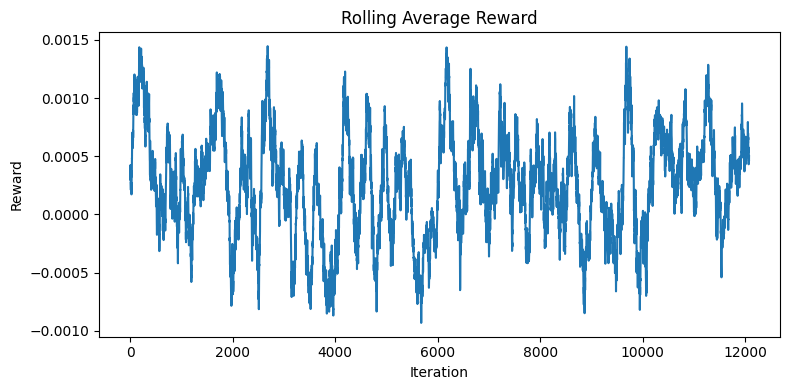

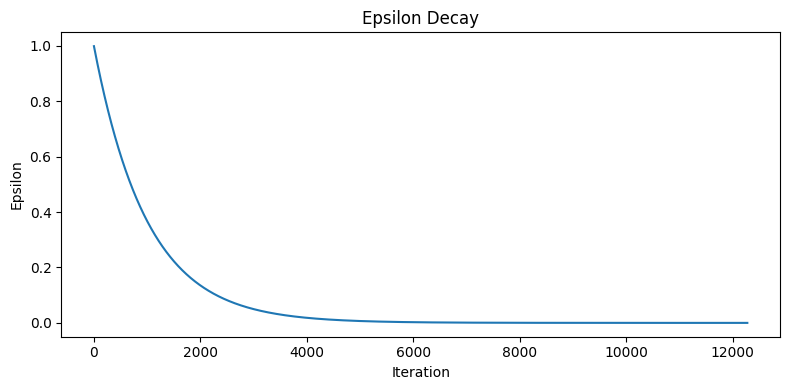

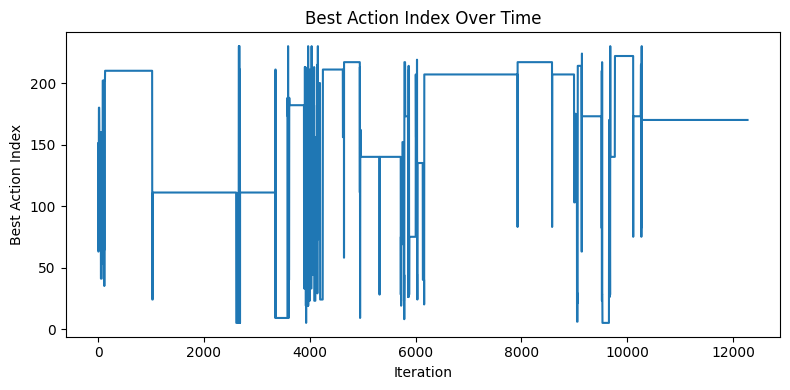

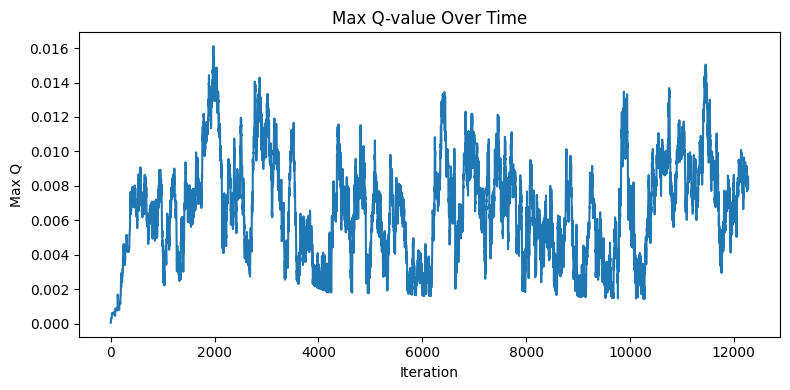

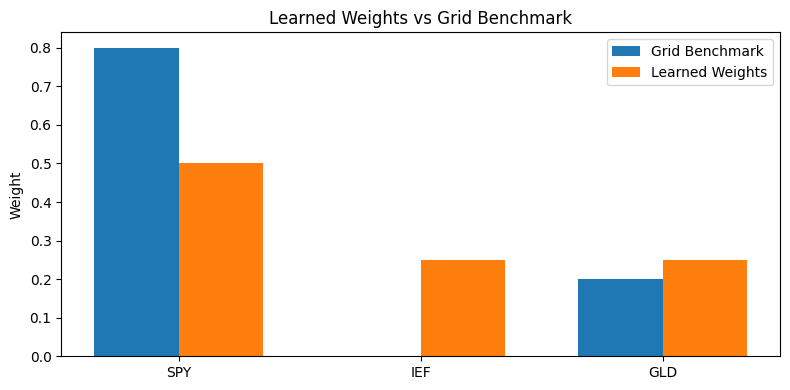

In [13]:
# 12. PLOTS
plot_training_results(result, rolling_window=200)
plot_weight_comparison(
    learned_weights=result["best_weights"],
    benchmark_weights=benchmark_weights,
    asset_names=asset_names
)